# 03b — Multi-frequency MIDAS (weekly target, daily + monthly predictors) — Python port

MIDAS is the mixed-frequency counterpart to the weekly ARIMAX / VAR / tree notebooks. The target is
the weekly W-FRI silver log-return, but genuinely daily predictors enter at their native frequency:
cross-asset returns, GS, FRED-rate changes, and forward-filled sentiment ablations each use K=20
trading-day lag paths. Monthly macro variables enter through publication-lagged monthly MIDAS blocks.
Only weekly-release variables (jobless + COT) remain one-week-lagged scalar controls. The notebook
uses restricted Beta / exp-Almon weights, then runs the same Drift-floor, RMSE/WDA, DM/PT, and ex-2025
evaluation battery as the other weekly models.


## 0. Model intuition

Let $y_t$ be the weekly silver return for forecast week $t$. A standard weekly regression would first
collapse a daily predictor into one weekly number. MIDAS keeps the recent daily path and learns how
much each high-frequency lag should matter.

For a daily predictor $x_j$, construct the public-information lag vector available before week $t$:

$$
\mathbf x_{j,t}^{(d)} =
\begin{bmatrix}
x_{j,t-1}^{(d)} & x_{j,t-2}^{(d)} & \cdots & x_{j,t-K}^{(d)}
\end{bmatrix}',
\qquad K=20.
$$

Restricted MIDAS replaces those $K$ separate coefficients with a normalized lag-weight curve:

$$
m_{j,t}(\theta_j) = \sum_{k=1}^{K} w_j(k;\theta_j) x_{j,t-k}^{(d)},
\qquad \sum_{k=1}^{K} w_j(k;\theta_j)=1.
$$

The forecast equation is therefore a weekly silver regression with compressed daily and monthly
histories:

$$
y_t = \alpha
+ \sum_{i=1}^{p}\phi_i y_{t-i}
+ \sum_j \beta_j m_{j,t}^{(d)}(\theta_j)
+ \sum_m \delta_m m_{m,t}^{(M)}(\eta_m)
+ \sum_q \gamma_q q_{q,t-1}
+ \varepsilon_t.
$$

Here $m_{j,t}^{(d)}$ are daily MIDAS blocks, $m_{m,t}^{(M)}$ are publication-lagged monthly macro
blocks, and $q_{q,t-1}$ are weekly-release controls such as jobless claims and COT. The key idea is
parsimony: instead of estimating 20 separate daily coefficients per variable, Beta or exp-Almon
weights estimate a smooth lag profile. That is what makes daily information usable in a weekly
forecast without turning the regression into an overfit kitchen sink.


## Setup

*Imports the numerical stack, plotting tools, and shared evaluation helpers.*

In [1]:
import sys, os
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
sys.path.append('../../src')
from eval_utils import evaluate, period_metrics, diebold_mariano, pesaran_timmermann, oos_r2, PERIODS

DATA = '../../data/processed/'
RAW  = '../../data/raw/'


## 1. Load & aggregate to weekly

*Loads the train/val/test splits and builds the W-FRI target frame. The notebook uses daily predictor lags, but the forecast target and evaluation grid are weekly, so `to_weekly()` is still needed for `silver_return`, split lengths, and weekly scalar controls.*

In [2]:
train = pd.read_csv(DATA+'train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv(DATA+'val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv(DATA+'test.csv',  index_col=0, parse_dates=True)

TARGET              = 'silver_return'
CROSS_ASSET_HF_VARS = ['gold_return','usd_return','copper_return','sp500_return','vix_return','oil_return']
GS_HF_VARS          = ['gs_ratio_z']
FRED_HF_VARS        = ['real_rates_chg','breakeven_chg']
FRED_WEEKLY_CHG_VARS = ['jobless_chg']
COT_STATE_VARS      = ['cot_mm_net_pct','cot_comm_net_pct']

# This weekly frame is only the target/evaluation skeleton plus true weekly-release controls.
# Daily HF predictors are intentionally not aggregated here; they stay in `daily` below and
# become K_DAILY-lag MIDAS matrices.
def to_weekly(df):
    # Returns and log-change variables add over time. `jobless_chg` is already
    # log(jobless_claims).diff(), so summing the mostly-zero daily values recovers
    # the weekly claims change. If we modeled raw jobless_claims levels, that would
    # belong in `last` instead.
    summ = [c for c in [TARGET] + FRED_WEEKLY_CHG_VARS if c in df.columns]
    # COT net-positioning ratios are weekly state variables forward-filled onto the daily grid.
    # Use the latest snapshot in the W-FRI bucket; the 1-week lag below handles Friday publication timing.
    last = [c for c in COT_STATE_VARS if c in df.columns]
    agg = {c: 'sum' for c in summ}
    agg.update({c: 'last' for c in last})
    return df.resample('W-FRI').agg(agg)

# Keep train/val/test weekly lengths separate for the later walk-forward split points.
train_w, val_w, test_w = to_weekly(train), to_weekly(val), to_weekly(test)
all_w   = pd.concat([train_w, val_w, test_w]).sort_index()
n_train = len(train_w) + len(val_w)
print(f'Weekly obs — train+val: {n_train}, test: {len(test_w)}')


Weekly obs — train+val: 417, test: 174


## 2. Base (silver AR) + weekly-release controls

*Builds weekly silver AR terms plus one-week-lagged jobless and COT controls.*

In [3]:
for k in (1,2,3):
    all_w[f'silver_lag{k}'] = all_w['silver_return'].shift(k)
# Jobless claims and COT are released weekly, so they remain weekly public-information controls.
for v in FRED_WEEKLY_CHG_VARS + COT_STATE_VARS:
    if v in all_w.columns:
        all_w[f'{v}_lag1'] = all_w[v].shift(1).fillna(0.0)

AR_LAGS   = [c for c in ['silver_lag1','silver_lag2','silver_lag3'] if c in all_w.columns]
JOBLESS_LAGS = [f'{v}_lag1' for v in FRED_WEEKLY_CHG_VARS if f'{v}_lag1' in all_w.columns]
COT_LAGS  = [f'{v}_lag1' for v in COT_STATE_VARS if f'{v}_lag1' in all_w.columns]
print('AR:', AR_LAGS, '| Jobless:', JOBLESS_LAGS, '| COT:', COT_LAGS)


AR: ['silver_lag1', 'silver_lag2', 'silver_lag3'] | Jobless: ['jobless_chg_lag1'] | COT: ['cot_mm_net_pct_lag1', 'cot_comm_net_pct_lag1']


## 3. Daily high-frequency blocks

*Constructs high-frequency daily lag matrices: cross-assets, GS, FRED-rate changes, and forward-filled sentiment blocks for ablations.*

In [4]:
# Raw train/val/test are daily frames. We concatenate them only to build lag matrices;
# the weekly train/val/test boundaries still come from train_w / val_w / test_w above.
daily = pd.concat([train, val, test]).sort_index()

# Sentiment is sparse. Forward-fill means: on each trading day, use the latest known
# sentiment score rather than treating non-news days as zero sentiment.
SENT_HF_VARS = ['reddit_sentiment','news_sentiment']   # TODO: does this make sense for gdelt news?
assert all(v in daily.columns for v in CROSS_ASSET_HF_VARS + GS_HF_VARS + FRED_HF_VARS + SENT_HF_VARS)
daily_hf = daily.copy()
daily_hf[SENT_HF_VARS] = daily_hf[SENT_HF_VARS].ffill()

# Number of daily observations fed into each MIDAS block: roughly one trading month.
K_DAILY = 20

def build_weekly_daily_lags(weekly_dates, s, k):
    """
    Build one daily-to-weekly MIDAS lag matrix.

    Input:
      weekly_dates: Friday labels for the weekly silver-return targets.
      s:            one daily predictor series, indexed by daily dates.
      k:            number of daily lags to keep.

    Output:
      matrix with shape (n_weeks, k). For row i:
        column 0     = newest daily observation available before that forecast week
        column k - 1 = oldest daily observation in the k-day window

    Rows with fewer than k usable daily observations remain NaN; the finite-row mask
    later drops those warm-up rows for variants that need them.
    """
    # Keep the values in a NumPy array for fast slicing, but keep s.index for date logic.
    values = s.values
    observed = ~np.isnan(values)
    lag_matrix = np.full((len(weekly_dates), k), np.nan)

    for i, week_end in enumerate(weekly_dates):
        # A W-FRI target week is labelled by its Friday. To forecast that week's
        # return, the model should only see information available before the week
        # starts. For a Friday label, week_end - 6 days is the preceding Saturday;
        # requiring s.index < cutoff means the newest allowed observation is the
        # previous Friday or earlier.
        public_info_cutoff = week_end - pd.Timedelta(days=6)

        # Keep only non-missing daily observations that pass the public-info cutoff.
        usable_history = observed & (s.index < public_info_cutoff)
        past_values = values[usable_history]

        if len(past_values) >= k:
            # Take the final k usable observations, then reverse so lag 1 is first.
            last_k_values = past_values[-k:]
            lag_matrix[i] = last_k_values[::-1]
    return lag_matrix

# Each dictionary below maps a readable MIDAS-series name to a weekly x K_DAILY
# lag matrix. The model later estimates one restricted Beta/Almon weight curve
# for each matrix.

# 1) Cross-asset daily returns: the canonical high-frequency EXOG block.
#    Example key: gold_return -> gold.
daily_lags = {}
for var in CROSS_ASSET_HF_VARS:
    midas_name = var.replace('_return', '')
    daily_lags[midas_name] = build_weekly_daily_lags(all_w.index, daily[var], K_DAILY)

# 2) GS ratio: daily level/z-score block, kept daily rather than collapsed weekly.
gs_hf_lags = {}
gs_hf_lags['gs_ratio_hf'] = build_weekly_daily_lags(all_w.index, daily['gs_ratio_z'], K_DAILY)

# 3) FRED market-rate changes: genuinely daily changes. Weekly jobless_chg is not here;
#    it is a weekly-release control handled in to_weekly() above.
fred_hf_lags = {}
for var in FRED_HF_VARS:
    midas_name = f'{var.replace("_chg", "")}_hf'
    fred_hf_lags[midas_name] = build_weekly_daily_lags(all_w.index, daily[var], K_DAILY)

# 4) Sentiment: use daily_hf, where sparse sentiment is forward-filled to the
#    latest known tone before building the lag path.
sent_hf_lags = {}
for var in SENT_HF_VARS:
    midas_name = var.replace('_sentiment', '_sent_hf')
    sent_hf_lags[midas_name] = build_weekly_daily_lags(all_w.index, daily_hf[var], K_DAILY)
print('Daily lag matrices:', {
    'cross_asset_hf': {v: m.shape for v, m in daily_lags.items()},
    'gs_hf':       {v: m.shape for v, m in gs_hf_lags.items()},
    'fred_hf':     {v: m.shape for v, m in fred_hf_lags.items()},
    'sent_hf_ffill': {v: m.shape for v, m in sent_hf_lags.items()},
})


Daily lag matrices: {'cross_asset_hf': {'gold': (591, 20), 'usd': (591, 20), 'copper': (591, 20), 'sp500': (591, 20), 'vix': (591, 20), 'oil': (591, 20)}, 'gs_hf': {'gs_ratio_hf': (591, 20)}, 'fred_hf': {'real_rates_hf': (591, 20), 'breakeven_hf': (591, 20)}, 'sent_hf_ffill': {'reddit_sent_hf': (591, 20), 'news_sent_hf': (591, 20)}}


### Look-ahead audit — daily block

*Audits that each high-frequency daily lag matrix only uses information available before the forecast week.*

In [5]:
position_fri = all_w.index - pd.Timedelta(days=7)
HF_LABELS = {'gs_ratio_z': 'gs_ratio_hf'}
for v in CROSS_ASSET_HF_VARS + GS_HF_VARS + FRED_HF_VARS + SENT_HF_VARS:
    s = daily_hf[v] if v in SENT_HF_VARS else daily[v]
    obs = s.notna().values; min_slack = np.inf
    for i, d in enumerate(all_w.index):
        keep = obs & (s.index < d - pd.Timedelta(days=6))
        if keep.any():
            min_slack = min(min_slack, (position_fri[i] - s.index[keep].max()).days)
    assert not (np.isfinite(min_slack) and min_slack < 0), f'look-ahead in daily {v}'
    label = HF_LABELS.get(v, v.replace('_return','').replace('_chg','_hf').replace('_sentiment','_sent_hf'))
    print(f'  {label:16s} OK  (min slack {int(min_slack)} d)')
print('Daily look-ahead audit passed.')


  gold             OK  (min slack 0 d)
  usd              OK  (min slack 0 d)
  copper           OK  (min slack 0 d)
  sp500            OK  (min slack 0 d)
  vix              OK  (min slack 0 d)
  oil              OK  (min slack 0 d)
  gs_ratio_hf      OK  (min slack 0 d)
  real_rates_hf    OK  (min slack 0 d)


  breakeven_hf     OK  (min slack 0 d)
  reddit_sent_hf   OK  (min slack 0 d)
  news_sent_hf     OK  (min slack 0 d)
Daily look-ahead audit passed.


*Prints one concrete MIDAS lag-matrix row so the daily-to-weekly structure is visible.*
TODO: decide if this cell below is optional

In [6]:
# Example: inspect one weekly forecast row from the daily MIDAS matrices.
# This does not fit a model; it just shows the data shape fed into MIDAS.
example_mats = {
    'gold': daily_lags['gold'],
    'gs_ratio_hf': gs_hf_lags['gs_ratio_hf'],
    'real_rates_hf': fred_hf_lags['real_rates_hf'],
    'news_sent_hf': sent_hf_lags['news_sent_hf'],
}

# Prefer a test-week example, but fall back to any fully finite row if needed.
candidate_rows = list(range(n_train, len(all_w))) + list(range(len(all_w)))
example_i = None
for i in candidate_rows:
    if all(np.isfinite(mat[i]).all() for mat in example_mats.values()):
        example_i = i
        break
if example_i is None:
    raise ValueError('No fully finite daily MIDAS example row found.')

example_week = all_w.index[example_i]
example_cutoff = example_week - pd.Timedelta(days=6)

def lag_dates_for_example(s, week_end, k):
    # Recreate the date labels for the lag row. The lag matrices store values only,
    # so this helper shows which daily dates those values came from.
    cutoff = week_end - pd.Timedelta(days=6)
    usable = s.notna().to_numpy() & (s.index < cutoff)
    return s.index[usable][-k:][::-1]

example_dates = lag_dates_for_example(daily['gold_return'], example_week, K_DAILY)
example_table = pd.DataFrame({
    'lag_col': [f'lag_{j:02d}' for j in range(1, K_DAILY + 1)],
    'daily_date_used': [d.date().isoformat() for d in example_dates],
})
for name, mat in example_mats.items():
    example_table[name] = mat[example_i]

print(f'Example weekly target row: {example_week.date()}')
print(f'Public-info cutoff:       {example_cutoff.date()}  (use daily dates strictly before this)')
print('lag_01 is newest available daily observation; lag_20 is oldest in the 20-day window.\n')
print(example_table.round(6).to_string(index=False))


Example weekly target row: 2023-01-06
Public-info cutoff:       2022-12-31  (use daily dates strictly before this)
lag_01 is newest available daily observation; lag_20 is oldest in the 20-day window.

lag_col daily_date_used      gold  gs_ratio_hf  real_rates_hf  news_sent_hf
 lag_01      2022-12-30  0.000110    -0.251667           0.02      0.009219
 lag_02      2022-12-29  0.006396    -0.329586          -0.04      0.009219
 lag_03      2022-12-28 -0.003809    -0.235613           0.02      0.009219
 lag_04      2022-12-27  0.010469    -0.338145           0.03     -0.022724
 lag_05      2022-12-23  0.004968    -0.328980           0.07     -0.022724
 lag_06      2022-12-22 -0.016043    -0.267312           0.07      0.164996
 lag_07      2022-12-21  0.000000    -0.331228          -0.04      0.059916
 lag_08      2022-12-20  0.015651    -0.352047           0.03      0.833052
 lag_09      2022-12-19 -0.001286    -0.097622           0.07      0.154275
 lag_10      2022-12-16  0.007177    -0

## 4. Monthly macro block — the second frequency

*Constructs publication-lagged monthly macro lag matrices using three recent monthly releases.*

In [7]:
macro = pd.read_csv(RAW+'monthly_macro.csv', index_col=0, parse_dates=True)
MACRO_VARS = ['cpi','fed_funds','ind_prod','m2']
assert all(v in macro.columns for v in MACRO_VARS), 'monthly_macro.csv missing a column'
# Quarterly macro memory. A five-release sensitivity was tested and did not improve OOS results.
N_MACRO_LAGS    = 3
MACRO_AVAIL_LAG = {'cpi':46,'ind_prod':48,'fed_funds':35,'m2':30}

def build_weekly_macro_lags(weekly_dates, s, lag_days, n_lags=N_MACRO_LAGS):
    avail = s.index + pd.Timedelta(days=lag_days)
    vals  = s.values; obs = ~np.isnan(vals)
    out   = np.full((len(weekly_dates), n_lags), np.nan)
    for i, d in enumerate(weekly_dates):
        keep = obs & (avail < d - pd.Timedelta(days=6))
        past = vals[keep]
        if len(past) >= n_lags:
            out[i] = past[-n_lags:][::-1]
    return out

macro_lags = {v: build_weekly_macro_lags(all_w.index, macro[v], MACRO_AVAIL_LAG[v]) for v in MACRO_VARS}
print('Macro lag matrices:', {v: m.shape for v, m in macro_lags.items()})


Macro lag matrices: {'cpi': (591, 3), 'fed_funds': (591, 3), 'ind_prod': (591, 3), 'm2': (591, 3)}


### Look-ahead audit — macro

*Audits that each monthly macro lag matrix only uses information available before the forecast week.*

In [8]:
position_fri = all_w.index - pd.Timedelta(days=7)
for v in MACRO_VARS:
    avail = macro.index + pd.Timedelta(days=MACRO_AVAIL_LAG[v]); obs = macro[v].notna().values
    min_slack = np.inf
    for i, d in enumerate(all_w.index):
        keep = obs & (avail < d - pd.Timedelta(days=6))
        if keep.any():
            min_slack = min(min_slack, (position_fri[i] - avail[keep].max()).days)
    assert not (np.isfinite(min_slack) and min_slack < 0), f'look-ahead in {v}'
    print(f'  {v:11s} OK  (min slack {int(min_slack)} d)')
print('Macro look-ahead audit passed.')


  cpi         OK  (min slack 0 d)
  fed_funds   OK  (min slack 0 d)
  ind_prod    OK  (min slack 0 d)
  m2          OK  (min slack 0 d)
Macro look-ahead audit passed.


## 5. Daily sentiment carry-forward check

*Summarizes the daily sentiment forward-fill used by the HF MIDAS sentiment block.*

In [9]:
sent_coverage = pd.DataFrame({
    'raw_non_null': daily[SENT_HF_VARS].notna().sum(),
    'ffill_non_null': daily_hf[SENT_HF_VARS].notna().sum(),
    'first_valid': [daily[v].first_valid_index() for v in SENT_HF_VARS],
})
print(sent_coverage.to_string())


                  raw_non_null  ffill_non_null first_valid
reddit_sentiment          2783            2783  2015-03-30
news_sentiment            1587            2150  2017-10-09


## 6. MIDAS weight functions and fitters

*Defines the restricted MIDAS lag-weight families used by the fitters.*

In [10]:
def nbeta_w(k, theta):
    th = np.maximum(theta, 0.1)
    x  = k / (k.max() + 1)
    w  = x**(th[0]-1) * (1-x)**(th[1]-1)
    w  = np.maximum(w, 1e-10)
    return w / w.sum()

def nealmon_w(k, theta):
    e = theta[0]*k + theta[1]*k**2
    e = e - e.max()
    w = np.exp(e)
    return w / w.sum()


*Defines the restricted MIDAS estimator, predictor, and finite-row mask.*

In [11]:
# Restricted MIDAS only (Beta/Almon): even the canonical daily block has 6x20=120 lags, so U-MIDAS would overfit.
def fit_with_midas(y, base_X, macro_list, weight_fn=nbeta_w, start=None, lower=None):
    names = list(macro_list); nmac = len(names)
    klists = {v: np.arange(1, macro_list[v].shape[1]+1) for v in names}
    if start is None: start = np.tile([1.0,5.0], nmac)
    if lower is None: lower = np.full(2*nmac, 0.1)
    base = np.asarray(base_X, float); y = np.asarray(y, float)
    def design(theta):
        cols = [macro_list[v] @ weight_fn(klists[v], theta[2*j:2*j+2]) for j, v in enumerate(names)]
        return np.column_stack([np.ones(len(y)), base, np.column_stack(cols)])
    def obj(theta):
        X = design(theta)
        if not np.all(np.isfinite(X)): return 1e9
        b, *_ = np.linalg.lstsq(X, y, rcond=None)
        r = y - X @ b
        return float(r @ r)
    res = minimize(obj, start, method='L-BFGS-B', bounds=[(lo, None) for lo in lower], options={'maxiter':1000})
    theta = res.x
    weights = {v: weight_fn(klists[v], theta[2*j:2*j+2]) for j, v in enumerate(names)}
    X = design(theta); b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return {'spec':'restricted','weights':weights,'coefs':b,'theta':theta,'names':names,'converged':bool(res.success)}

def predict_with_midas(fit, base_X, macro_list):
    base = np.asarray(base_X, float)
    cols = [macro_list[v] @ fit['weights'][v] for v in fit['names']]
    X = np.column_stack([np.ones(len(base)), base, np.column_stack(cols)])
    return X @ fit['coefs']

def make_mask(y, base_X, mlist):
    m = ~np.isnan(y) & ~np.isnan(np.asarray(base_X, float)).any(axis=1)
    for v in mlist: m = m & ~np.isnan(mlist[v]).any(axis=1)
    return m


## 7. Two-stage protocol — spec selection, then walk-forward ladder
**Stage 1** picks Beta vs Almon by val RMSE on the combined multi-frequency list, while reporting
the WDA winner as the secondary directional lens. **Stage 2**
walk-forwards (expanding, refit every 4 weeks). Genuinely daily variables enter as MIDAS blocks
(`+GS_HF`, `+FRED_HF`, `+Sentiment_HF`); weekly-release variables enter only as `+Jobless` and `+COT` controls.
Clean macro-combination rungs are included before the broader `ALL_HF` variant.


*Selects the weight family, runs the pure daily-HF ablation ladder, and stores predictions.*

In [12]:
y_all  = all_w['silver_return'].values
ar_all = all_w[AR_LAGS].values
idx    = np.arange(len(all_w)); n_train_only = len(train_w)
sub    = lambda rm, ml: {v: ml[v][rm] for v in ml}
mf_all = {**daily_lags, **macro_lags}

mask  = make_mask(y_all, ar_all, mf_all)
m_tr1 = mask & (idx <  n_train_only)
m_v   = mask & (idx >= n_train_only) & (idx < n_train)
kk = len(mf_all)
print(f'Stage 1 — {kk} MIDAS series: {len(daily_lags)} daily + {len(macro_lags)} monthly')
fits1 = {
  'Beta-MIDAS':  fit_with_midas(y_all[m_tr1], ar_all[m_tr1], sub(m_tr1, mf_all), nbeta_w,  np.tile([1.,5.],kk), np.full(2*kk, 0.1)),
  'Almon-MIDAS': fit_with_midas(y_all[m_tr1], ar_all[m_tr1], sub(m_tr1, mf_all), nealmon_w, np.tile([0.,0.],kk), np.full(2*kk, -5.0)),
}
s1 = [evaluate(nm, y_all[m_v], predict_with_midas(ft, ar_all[m_v], sub(m_v, mf_all))) for nm, ft in fits1.items()]
best_spec = min(s1, key=lambda r: r['rmse'])['model']
best_wda_spec = max(s1, key=lambda r: r['wda'])['model']
print('=> winner by val RMSE:', best_spec, '| WDA winner:', best_wda_spec)
pd.DataFrame(s1).to_csv(DATA+'midas_daily_stage1_specs.csv', index=False)

# ── Stage 2 ──────────────────────────────────────────────────────────────────
RETRAIN_EVERY = 4
ar_F = ar_all[mask]
jobless_F = all_w[JOBLESS_LAGS].values[mask]
cot_F = all_w[COT_LAGS].values[mask]
daily_F = sub(mask, daily_lags); macro_F = sub(mask, macro_lags)
gs_hf_F = sub(mask, gs_hf_lags); fred_hf_F = sub(mask, fred_hf_lags); sent_hf_F = sub(mask, sent_hf_lags)
dates_F = all_w.index[mask]; orig = idx[mask]; test_pos = np.where(orig >= n_train)[0]
y_F = y_all[mask]; y_te = y_F[test_pos]; dates_te = dates_F[test_pos]
weekly_control_parts = [x for x in [jobless_F, cot_F] if x.shape[1] > 0]
weekly_controls_F = np.column_stack(weekly_control_parts) if weekly_control_parts else np.empty((len(ar_F), 0))
weekly_base_F = np.column_stack([ar_F, weekly_controls_F]) if weekly_controls_F.shape[1] else ar_F

def fit_restricted(y, baseX, mlist):
    k = len(mlist)
    if best_spec == 'Beta-MIDAS': return fit_with_midas(y, baseX, mlist, nbeta_w,  np.tile([1.,5.],k), np.full(2*k, 0.1))
    return fit_with_midas(y, baseX, mlist, nealmon_w, np.tile([0.,0.],k), np.full(2*k, -5.0))

def finite_rows(y, baseX, mlist):
    m = ~np.isnan(y) & ~np.isnan(np.asarray(baseX, float)).any(axis=1)
    for v in mlist:
        m = m & ~np.isnan(mlist[v]).any(axis=1)
    return m

def walk_forward(baseX, mlist):
    preds = np.full(len(test_pos), np.nan); fit = None
    for j, p in enumerate(test_pos):
        if j % RETRAIN_EVERY == 0:
            hist = {v: mlist[v][:p] for v in mlist}
            hm = finite_rows(y_F[:p], baseX[:p], hist)
            fit = fit_restricted(y_F[:p][hm], baseX[:p][hm], {v: hist[v][hm] for v in hist})
        now = {v: mlist[v][p:p+1] for v in mlist}
        if finite_rows(y_F[p:p+1], baseX[p:p+1], now).all():
            preds[j] = predict_with_midas(fit, baseX[p:p+1], now)[0]
    return preds

all_preds = {}; all_results = []
def run_variant(label, baseX, mlist):
    all_preds[label] = walk_forward(baseX, mlist)
    all_results.append(evaluate(label, y_te, all_preds[label]))

all_preds['Naive (t-1 week)'] = np.concatenate([[np.nan], y_te[:-1]])
all_results.append(evaluate('Naive (t-1 week)', y_te, all_preds['Naive (t-1 week)']))
all_preds['Drift (prevailing mean)'] = np.array([y_F[:p].mean() for p in test_pos])
all_results.append(evaluate('Drift (prevailing mean)', y_te, all_preds['Drift (prevailing mean)']))

run_variant('EXOG-d',       ar_F, daily_F)
run_variant('EXOG-d+Macro', ar_F, {**daily_F, **macro_F})
run_variant('EXOG-d+GS_HF', ar_F, {**daily_F, **gs_hf_F})
run_variant('EXOG-d+Macro+GS_HF', ar_F, {**daily_F, **macro_F, **gs_hf_F})
run_variant('EXOG-d+FRED_HF', ar_F, {**daily_F, **fred_hf_F})
run_variant('EXOG-d+Macro+FRED_HF', ar_F, {**daily_F, **macro_F, **fred_hf_F})
run_variant('EXOG-d+GS_HF+FRED_HF', ar_F, {**daily_F, **gs_hf_F, **fred_hf_F})
run_variant('EXOG-d+Macro+GS_HF+FRED_HF', ar_F, {**daily_F, **macro_F, **gs_hf_F, **fred_hf_F})
if len(JOBLESS_LAGS):
    run_variant('EXOG-d+Jobless', np.column_stack([ar_F, jobless_F]), daily_F)
if len(COT_LAGS):
    run_variant('EXOG-d+COT', np.column_stack([ar_F, cot_F]), daily_F)
run_variant('EXOG-d+FRED_HF+Jobless+COT', weekly_base_F, {**daily_F, **fred_hf_F})
run_variant('EXOG-d+Macro+FRED_HF+Jobless+COT', weekly_base_F, {**daily_F, **macro_F, **fred_hf_F})
run_variant('EXOG-d+ALL_NO_SENT_HF', weekly_base_F, {**daily_F, **macro_F, **gs_hf_F, **fred_hf_F})
run_variant('EXOG-d+Sentiment_HF', ar_F, {**daily_F, **sent_hf_F})
run_variant('EXOG-d+FRED_HF+Sentiment_HF', ar_F, {**daily_F, **fred_hf_F, **sent_hf_F})
run_variant('EXOG-d+GS_HF+Sentiment_HF', ar_F, {**daily_F, **gs_hf_F, **sent_hf_F})
run_variant('EXOG-d+ALL_HF', weekly_base_F, {**daily_F, **macro_F, **gs_hf_F, **fred_hf_F, **sent_hf_F})

L = test_pos[-1] + 1; mfL = {**daily_F, **macro_F}
fit_em = fit_restricted(y_F[:L], ar_F[:L], {v: mfL[v][:L] for v in mfL})


Stage 1 — 10 MIDAS series: 6 daily + 4 monthly


Beta-MIDAS                                     RMSE=0.05129  MAE=0.04146  DA=0.500  WDA=0.450
Almon-MIDAS                                    RMSE=0.05001  MAE=0.04140  DA=0.365  WDA=0.404
=> winner by val RMSE: Almon-MIDAS | WDA winner: Beta-MIDAS
Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03713  DA=0.557  WDA=0.588


EXOG-d                                         RMSE=0.05254  MAE=0.03788  DA=0.546  WDA=0.542


EXOG-d+Macro                                   RMSE=0.05323  MAE=0.03909  DA=0.494  WDA=0.561


EXOG-d+GS_HF                                   RMSE=0.05163  MAE=0.03656  DA=0.603  WDA=0.618


...

EXOG-d+ALL_NO_SENT_HF                          RMSE=0.05315  MAE=0.03786  DA=0.552  WDA=0.567


EXOG-d+Sentiment_HF                            RMSE=0.05329  MAE=0.03852  DA=0.552  WDA=0.556


EXOG-d+FRED_HF+Sentiment_HF                    RMSE=0.05346  MAE=0.03866  DA=0.511  WDA=0.512


EXOG-d+GS_HF+Sentiment_HF                      RMSE=0.05365  MAE=0.03812  DA=0.592  WDA=0.522


EXOG-d+ALL_HF                                  RMSE=0.05662  MAE=0.04033  DA=0.477  WDA=0.430


## 8. Results table

*Compiles full-sample metrics, adds OOS R² versus Drift, and writes the metrics CSV.*

In [13]:
metrics_df = pd.DataFrame(all_results)
drift_p = all_preds['Drift (prevailing mean)']
metrics_df['oos_r2'] = [oos_r2(y_te, all_preds[m], drift_p) for m in metrics_df['model']]
metrics_df.to_csv(DATA+'metrics_midas_daily_weekly.csv', index=False)
print(metrics_df.round(6).to_string(index=False))


                           model     rmse      mae  dir_acc      wda    oos_r2
                Naive (t-1 week) 0.075941 0.053966 0.491329 0.489862 -1.129014
         Drift (prevailing mean) 0.051897 0.037132 0.557471 0.587779  0.000000
                          EXOG-d 0.052537 0.037875 0.545977 0.542258 -0.024829
                    EXOG-d+Macro 0.053228 0.039089 0.494253 0.561222 -0.051973
                    EXOG-d+GS_HF 0.051632 0.036563 0.603448 0.617704  0.010170
              EXOG-d+Macro+GS_HF 0.052745 0.037251 0.528736 0.509936 -0.032957
                  EXOG-d+FRED_HF 0.053116 0.037363 0.540230 0.511143 -0.047534
            EXOG-d+Macro+FRED_HF 0.053259 0.038284 0.574713 0.568662 -0.053164
            EXOG-d+GS_HF+FRED_HF 0.052723 0.037738 0.551724 0.530043 -0.032082
      EXOG-d+Macro+GS_HF+FRED_HF 0.052318 0.036827 0.574713 0.551023 -0.016278
                  EXOG-d+Jobless 0.052606 0.037588 0.591954 0.592307 -0.027526
                      EXOG-d+COT 0.052497 0.038055 0

### Always-up directional benchmark

*Prints the per-period always-up WDA benchmark implied by the Drift sign.*

In [14]:
print('Always-up WDA by period (directional benchmark to beat):')
_s = pd.Series(y_te, index=dates_te)
for lbl, (a, b) in PERIODS.items():
    sub_ = _s.loc[a:b]
    if len(sub_) < 4: continue
    au = np.sum(np.abs(sub_.values) * (sub_.values > 0)) / np.sum(np.abs(sub_.values))
    print(f'  {lbl:22s} always-up WDA = {au:.3f}  (n={len(sub_)})')


Always-up WDA by period (directional benchmark to beat):
  2023  (choppy)         always-up WDA = 0.492  (n=52)
  2024  (bull start)     always-up WDA = 0.570  (n=52)
  2025  (bull run)       always-up WDA = 0.757  (n=52)
  2026  (YTD)            always-up WDA = 0.498  (n=18)
  ── Full test ──        always-up WDA = 0.588  (n=174)


## 9. Fitted lag-weight profiles (EXOG-d+Macro)

*Plots the fitted daily and monthly MIDAS lag-weight profiles for the macro headline fit.*

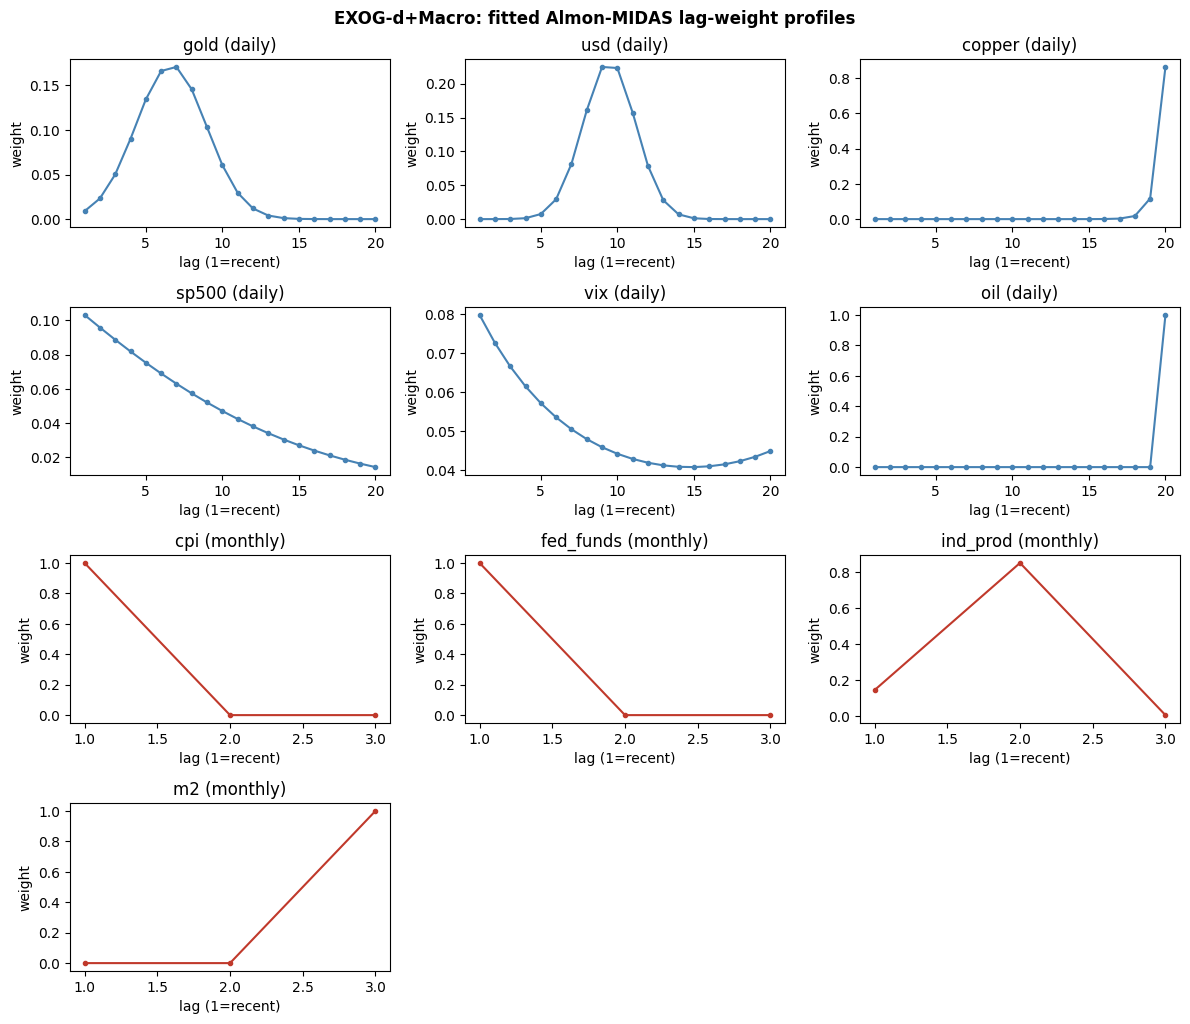

In [15]:
ws = fit_em['weights']; vs = list(ws); ncol = 3; nrow = int(np.ceil(len(vs)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 2.6*nrow)); axes = np.atleast_1d(axes).ravel()
for ax, v in zip(axes, vs):
    w = ws[v]; col = 'steelblue' if len(w) > 5 else '#c0392b'
    ax.plot(range(1, len(w)+1), w, '-o', ms=3, color=col)
    ax.set_title(f'{v} ({"daily" if len(w)>5 else "monthly"})'); ax.set_xlabel('lag (1=recent)'); ax.set_ylabel('weight')
for ax in axes[len(vs):]: ax.axis('off')
fig.suptitle(f'EXOG-d+Macro: fitted {best_spec} lag-weight profiles', fontweight='bold')
plt.tight_layout(); plt.show()


## 10. Period breakdown — best by WDA *and* by RMSE

*Selects WDA-best and RMSE-best variants, then saves period metrics and predictions.*

In [16]:
cand = metrics_df[~metrics_df['model'].isin(['Naive (t-1 week)','Drift (prevailing mean)'])]
best_wda  = cand.loc[cand['wda'].idxmax(),  'model']
best_rmse = cand.loc[cand['rmse'].idxmin(), 'model']
print(f'Best by WDA: {best_wda}   |   Best by RMSE: {best_rmse}')
for tag, bn, fper, fpred in [('WDA',  best_wda,  'period_midas_daily_weekly.csv',      'preds_midas_daily_best_weekly.csv'),
                             ('RMSE', best_rmse, 'period_midas_daily_rmse_weekly.csv', 'preds_midas_daily_bestrmse_weekly.csv')]:
    bp = all_preds[bn]
    pp = period_metrics(np.asarray(y_te), np.asarray(bp), dates_te, PERIODS)
    pp.to_csv(DATA+fper)
    pd.DataFrame({'Date': dates_te, 'actual': y_te, 'predicted': bp}).to_csv(DATA+fpred, index=False)
    print(f'\n[{tag}-best = {bn}]'); print(pp.round(3))
best_name, best_pred = best_wda, all_preds[best_wda]


Best by WDA: EXOG-d+GS_HF   |   Best by RMSE: EXOG-d+GS_HF

[WDA-best = EXOG-d+GS_HF]
                      n   RMSE    MAE     DA    WDA
Period                                             
2023  (choppy)       52  0.040  0.031  0.500  0.550
2024  (bull start)   52  0.035  0.028  0.692  0.795
2025  (bull run)     52  0.052  0.035  0.635  0.587
2026  (YTD)          18  0.099  0.081  0.556  0.543
── Full test ──     174  0.052  0.037  0.603  0.618

[RMSE-best = EXOG-d+GS_HF]
                      n   RMSE    MAE     DA    WDA
Period                                             
2023  (choppy)       52  0.040  0.031  0.500  0.550
2024  (bull start)   52  0.035  0.028  0.692  0.795
2025  (bull run)     52  0.052  0.035  0.635  0.587
2026  (YTD)          18  0.099  0.081  0.556  0.543
── Full test ──     174  0.052  0.037  0.603  0.618


## 11. Significance tests
Primary DM-vs-Drift floor (se + ae) + OOS R²; secondary incremental vs `EXOG-d`, and
Pesaran-Timmermann (per-variant + multiple-testing summary + per-period for the best variant).
DM calls use the shared convention: `pred1` = Drift, so positive DM means the MIDAS variant
has lower loss than the random-walk-with-drift floor.


*Runs the Drift-floor significance battery plus secondary incremental and directional tests.*

In [17]:
drift_p = all_preds['Drift (prevailing mean)']
variant_names = [nm for nm in all_preds if nm not in ('Drift (prevailing mean)', 'Naive (t-1 week)')]
print('Floor test — each variant vs Drift   [primary]'); print('-'*92)
for nm in variant_names:
    print(f'{nm:26s}  OOS_R2={oos_r2(y_te, all_preds[nm], drift_p):+.4f}')
    diebold_mariano(y_te, drift_p, all_preds[nm], 'Drift', nm, loss='se')
    diebold_mariano(y_te, drift_p, all_preds[nm], 'Drift', nm, loss='ae')
print('\nIncremental test — each variant vs EXOG-d   [secondary]'); print('-'*92)
for nm in variant_names:
    if nm == 'EXOG-d': continue
    diebold_mariano(y_te, all_preds['EXOG-d'], all_preds[nm], 'EXOG-d', nm, loss='se')
print('\nPesaran-Timmermann — directional   [secondary]'); print('-'*92)
for nm in variant_names:
    pesaran_timmermann(y_te, all_preds[nm], name=nm)

pts = {nm: pesaran_timmermann(y_te, all_preds[nm]) for nm in variant_names}
sig = [nm for nm, r in pts.items() if r and r.get('p') is not None and np.isfinite(r['p']) and r['p'] < 0.05]
nt = len(pts)
print(f'\nPT multiple-testing: {len(sig)}/{nt} significant at p<0.05  (~{0.05*nt:.1f} expected by chance)')
if sig: print('  significant:', sig)
print(f'  (best-by-WDA is the max over ~{nt} ablations — single-variant PT hits are selection-biased)')
print(f'\nPer-period PT — best variant ({best_name}):')
_s = pd.Series(y_te, index=dates_te); _p = pd.Series(best_pred, index=dates_te)
for lbl, (a, b) in PERIODS.items():
    yy = _s.loc[a:b].values; pp = _p.loc[a:b].values
    if len(yy) < 12: continue
    pesaran_timmermann(yy, pp, name=f'  {lbl}')


Floor test — each variant vs Drift   [primary]
--------------------------------------------------------------------------------------------
EXOG-d                      OOS_R2=-0.0248
Drift                                    vs EXOG-d                                    DM=-0.982  p=0.326  (ns)  -> winner: tie
Drift                                    vs EXOG-d                                    DM=-1.239  p=0.215  (ns)  -> winner: tie
EXOG-d+Macro                OOS_R2=-0.0520
Drift                                    vs EXOG-d+Macro                              DM=-1.388  p=0.165  (ns)  -> winner: tie
Drift                                    vs EXOG-d+Macro                              DM=-2.288  p=0.022  *     -> winner: Drift
EXOG-d+GS_HF                OOS_R2=+0.0102
Drift                                    vs EXOG-d+GS_HF                              DM=+0.229  p=0.819  (ns)  -> winner: tie
Drift                                    vs EXOG-d+GS_HF                              DM=+0.62

## 12. Robustness — drop the 2025 bull run (full battery)

2025 carries much of the always-up line, so once the full-window tests are done, re-run **the whole
battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026** only. Evaluation-only
(forecasts unchanged, still trained walk-forward through 2025); pooled for DM power.

*Repeats the full evaluation battery after excluding the 2025 bull-run year.*

In [18]:
# Full battery on the non-bull window. Evaluation-only (forecasts unchanged); pooled for DM power.
mask_ex25 = np.asarray(dates_te.year != 2025)
a_ex      = np.asarray(y_te)[mask_ex25]
drift_ex  = np.asarray(drift_p)[mask_ex25]
variant_names = [nm for nm in all_preds if nm not in ('Drift (prevailing mean)', 'Naive (t-1 week)')]
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
evaluate('Drift (prevailing mean)', a_ex, drift_ex)
for nm in variant_names:
    evaluate(nm, a_ex, np.asarray(all_preds[nm])[mask_ex25])

print('\nOOS R^2 vs Drift (2025 excluded) -- >0 beats the random walk:')
print('-' * 90)
for nm in variant_names:
    _r2 = oos_r2(a_ex, np.asarray(all_preds[nm])[mask_ex25], drift_ex) * 100
    print(f'  {nm:40s} R2_OS = {_r2:+6.2f}%   -> winner: {nm if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for nm in variant_names:
    diebold_mariano(a_ex, drift_ex, np.asarray(all_preds[nm])[mask_ex25], 'Drift', nm)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for nm in variant_names:
    diebold_mariano(a_ex, drift_ex, np.asarray(all_preds[nm])[mask_ex25], 'Drift', nm, loss='ae')

print('\nPesaran-Timmermann (2025 excluded) -- directional sign test:')
print('-' * 90)
for nm in variant_names:
    pesaran_timmermann(a_ex, np.asarray(all_preds[nm])[mask_ex25], name=nm)


Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
Drift (prevailing mean)                        RMSE=0.05276  MAE=0.03797  DA=0.500  WDA=0.520
EXOG-d                                         RMSE=0.05285  MAE=0.03827  DA=0.574  WDA=0.578
EXOG-d+Macro                                   RMSE=0.05353  MAE=0.03967  DA=0.533  WDA=0.608
EXOG-d+GS_HF                                   RMSE=0.05168  MAE=0.03718  DA=0.590  WDA=0.630
EXOG-d+Macro+GS_HF                             RMSE=0.05233  MAE=0.03686  DA=0.582  WDA=0.557
EXOG-d+FRED_HF                                 RMSE=0.05323  MAE=0.03738  DA=0.557  WDA=0.535
EXOG-d+Macro+FRED_HF                           RMSE=0.05396  MAE=0.03926  DA=0.566  WDA=0.593
EXOG-d+GS_HF+FRED_HF                           RMSE=0.05224  MAE=0.03769  DA=0.566  WDA=0.553
EXOG-d+Macro+GS_HF+FRED_HF                     RMSE=0.05222  MAE=0.03713  DA=0.590  WDA=0.578
EXOG-d+Jobless                                 RMSE

## 13. 2026 zoom — WDA-best and RMSE-best (vs Drift)

*Plots the 2026 slice for the WDA-best and RMSE-best variants against Drift.*

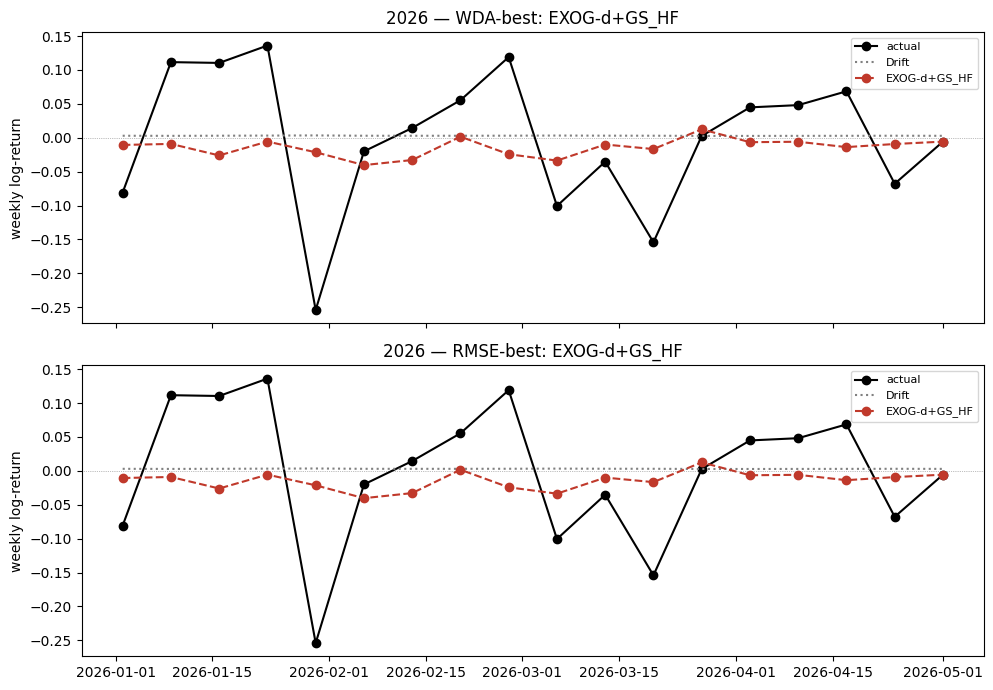

In [19]:
m26 = dates_te >= pd.Timestamp('2026-01-01')
if m26.any():
    drift_p = all_preds['Drift (prevailing mean)']
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    for ax, (tag, bn) in zip(axes, [('WDA', best_wda), ('RMSE', best_rmse)]):
        bp = np.asarray(all_preds[bn])
        ax.axhline(0, color='grey', ls=':', lw=.5)
        ax.plot(dates_te[m26], np.asarray(y_te)[m26], 'k-o', label='actual')
        ax.plot(dates_te[m26], np.asarray(drift_p)[m26], ':', color='grey', label='Drift')
        ax.plot(dates_te[m26], bp[m26], '--o', color='#c0392b', label=bn)
        ax.set_title(f'2026 — {tag}-best: {bn}'); ax.set_ylabel('weekly log-return'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('No 2026 data in test set yet.')
